# 02 — Feature Engineering

**Dataset:** Inside Airbnb — New York City (open data)  
**Goal:** Build a flat feature matrix per listing ready for modelling.

We engineer features from four sources:
1. **Calendar behaviour** (Q3+Q4 2025) — blocking rates, weekend patterns, status transitions, monthly trends, recency.
2. **Property metadata** (December 2025 snapshot) — 5-month (Jul-Nov 2025) price + trend/volatility, ratings, amenities, host tenure, availability, geography.
3. **Review velocity** (December 2025 reviews) — review counts over 30 / 90 / 180 / 365-day windows.
4. **Target** (clean multi-snapshot rule, Oct 2025 - Mar 2026 calendars) — `blocked_days_Q1_2026`.

**Key differences from old Kaggle pipeline:**
- `available ∈ {t, f}` replaces `Status ∈ {A, B, R}` — no B/R distinction.
- Price is genuinely sparse in the open Inside Airbnb export (~55-59%/month, December 100%
  empty) vs. the complete pricing in the proprietary 2016 Kaggle data — mitigated by averaging
  across 5 months, a neighbourhood-relative price, and an explicit `price_missing` flag.
- No pre-defined train/test split → **80/20 random split** on labeled data.
- Richer metadata: 85 cols vs 33 cols in old `property_info.csv`.
- Target uses a **clean multi-snapshot rule** (real available→booked transition, seen in ≥2 of
  6 monthly snapshots) instead of a single December snapshot's forward view — this removes
  host-block/dead-listing noise that was inflating target variance (see Section 6).

**Outputs:**
- `outputs/train_local.parquet` — 80% for model training + CV
- `outputs/test_local.parquet` — 20% for final evaluation
- `outputs/all_features.parquet` — full labeled dataset (for ensemble notebooks)

---
### Outline
1. Setup
2. Paths & Config
3. Calendar Features (Q3+Q4 2025)
4. Property Metadata (December 2025)
5. Review Velocity
6. Derive Target
7. Merge All Features
8. Feature Summary & Correlations
9. Train / Test Split & Save

## 1. Setup

In [1]:
import ast
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

NumPy: 2.4.6 | Pandas: 3.0.3


## 2. Paths & Config

In [2]:
BASE_DIR = Path('../AirBnb_Inside')
Q3_DIR   = BASE_DIR / '2025_Inside_Airbnb/Q3'
Q4_DIR   = BASE_DIR / '2025_Inside_Airbnb/Q4'
DEC_DIR  = Q4_DIR / 'December2025'
NOV_DIR  = Q4_DIR / 'November2025'
OUT_DIR  = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True, parents=True)

# Each tuple: (label, calendar_path, start_date, end_date)
# We filter each month's scrape to its own date range to build a
# continuous 6-month H2 2025 availability record.
MONTH_CONFIGS = [
    ('Jul', Q3_DIR / 'July2025'      / 'calendar.csv', '2025-07-01', '2025-07-31'),
    ('Aug', Q3_DIR / 'August2025'    / 'calendar.csv', '2025-08-02', '2025-08-31'),
    ('Sep', Q3_DIR / 'September2025' / 'calendar.csv', '2025-09-02', '2025-09-30'),
    ('Oct', Q4_DIR / 'October2025'   / 'calendar.csv', '2025-10-01', '2025-10-31'),
    ('Nov', Q4_DIR / 'November2025'  / 'calendar.csv', '2025-11-02', '2025-11-30'),
    ('Dec', Q4_DIR / 'December2025'  / 'calendar.csv', '2025-12-04', '2025-12-31'),
]

print('Data root:', BASE_DIR.resolve())
print('Output  :', OUT_DIR.resolve())

Data root: /Users/bashkal/Desktop/ML/ML-Final/Internship/AirBnb_Inside
Output  : /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs


In [3]:
def detailed_listings_path(month_dir):
    """Return path of the detailed (79+ col) listings file for a month directory."""
    for fname in ['listings.csv', 'listings-2.csv']:
        p = Path(month_dir) / fname
        with open(p) as f:
            ncols = len(f.readline().split(','))
        if ncols > 30:
            return p
    raise FileNotFoundError(f'No detailed listings file in {month_dir}')

## 3. Calendar Features (Q3+Q4 2025)

We load each monthly scrape filtered to its own calendar month, then concatenate into one
H2 2025 DataFrame. From this we compute Q3, Q4, H2-combined, and monthly-breakdown aggregates.

Minor gaps: August scrape starts Aug 2 (miss Aug 1); December starts Dec 4 (miss Dec 1–3).

In [4]:
def load_calendar_month(cal_path, start, end):
    df = pd.read_csv(
        cal_path,
        usecols=['listing_id', 'date', 'available'],
        dtype={'listing_id': 'int64', 'available': 'category'},
    )
    df['date'] = pd.to_datetime(df['date'])
    return df[(df['date'] >= start) & (df['date'] <= end)].copy()

print(f'{"Month":<5} {"Rows":>10} {"Listings":>10} {"Block rate":>12}')
print('-' * 42)
parts = []
for label, cal_path, start, end in MONTH_CONFIGS:
    m_df = load_calendar_month(cal_path, start, end)
    m_df['month_num'] = pd.to_datetime(start).month
    parts.append(m_df)
    br = (m_df['available'] == 'f').mean()
    print(f'{label:<5} {len(m_df):>10,} {m_df["listing_id"].nunique():>10,} {br:>12.3f}')

h2_cal = pd.concat(parts, ignore_index=True)
del parts
print(f'\nH2 combined: {len(h2_cal):,} rows | {h2_cal["listing_id"].nunique():,} unique listings')

Month       Rows   Listings   Block rate
------------------------------------------


Jul    1,093,964     36,345        0.702


Aug    1,080,922     36,403        0.660


Sep    1,047,224     36,178        0.708


Oct    1,085,967     36,111        0.709


Nov    1,045,723     36,353        0.670


Dec      982,765     36,261        0.649

H2 combined: 6,336,565 rows | 40,479 unique listings


In [5]:
def agg_calendar(cal_df, prefix):
    """Per-listing calendar feature aggregation for a given time window."""
    cal = cal_df[['listing_id', 'date', 'available']].copy()
    cal['is_blocked'] = (cal['available'] == 'f').astype('int8')
    cal['is_avail']   = (cal['available'] == 't').astype('int8')
    cal['is_weekend'] = cal['date'].dt.dayofweek.isin([4, 5]).astype('int8')  # Fri + Sat

    # Core blocking stats
    core = cal.groupby('listing_id').agg(
        days_total   = ('is_blocked', 'count'),
        days_blocked = ('is_blocked', 'sum'),
        days_avail   = ('is_avail',   'sum'),
    )
    core['blocking_rate'] = core['days_blocked'] / core['days_total']
    core['avail_rate']    = core['days_avail']   / core['days_total']

    # Weekend vs weekday blocking
    we = cal[cal['is_weekend'] == 1].groupby('listing_id')['is_blocked'].agg(
        we_days='count', we_blocked='sum')
    wd = cal[cal['is_weekend'] == 0].groupby('listing_id')['is_blocked'].agg(
        wd_days='count', wd_blocked='sum')
    we['we_blocking_rate'] = we['we_blocked'] / we['we_days'].replace(0, np.nan)
    wd['wd_blocking_rate'] = wd['wd_blocked'] / wd['wd_days'].replace(0, np.nan)

    # Status transitions (available→blocked = new booking proxy)
    cal_s = cal.sort_values(['listing_id', 'date'])
    cal_s['prev_avail']     = cal_s.groupby('listing_id')['is_avail'].shift(1)
    cal_s['new_blocking']   = ((cal_s['is_avail'] == 0) & (cal_s['prev_avail'] == 1)).astype('int8')
    cal_s['new_unblocking'] = ((cal_s['is_avail'] == 1) & (cal_s['prev_avail'] == 0)).astype('int8')
    trans = cal_s.groupby('listing_id').agg(
        new_blockings   = ('new_blocking',   'sum'),
        new_unblockings = ('new_unblocking', 'sum'),
    )

    result = (core
              .join(we[['we_blocking_rate', 'we_days']])
              .join(wd[['wd_blocking_rate', 'wd_days']])
              .join(trans))
    result['we_minus_wd_blocking'] = result['we_blocking_rate'] - result['wd_blocking_rate']

    result.columns = [f'{prefix}_{c}' for c in result.columns]
    result.index.name = 'listing_id'
    return result.reset_index()

In [6]:
q3_mask = h2_cal['date'] < '2025-10-01'
q4_mask = h2_cal['date'] >= '2025-10-01'

print('Computing Q3 2025 aggregates (Jul–Sep)...')
agg_q3 = agg_calendar(h2_cal[q3_mask], 'q3')
print(f'  Shape: {agg_q3.shape}')

print('Computing Q4 2025 aggregates (Oct–Dec)...')
agg_q4 = agg_calendar(h2_cal[q4_mask], 'q4')
print(f'  Shape: {agg_q4.shape}')

print('Computing H2 2025 combined aggregates...')
agg_h2 = agg_calendar(h2_cal, 'h2')
print(f'  Shape: {agg_h2.shape}')

print('\nSample Q3 aggregates:')
print(agg_q3.head(3).to_string(index=False))

Computing Q3 2025 aggregates (Jul–Sep)...


  Shape: (38203, 13)
Computing Q4 2025 aggregates (Oct–Dec)...


  Shape: (38077, 13)
Computing H2 2025 combined aggregates...


  Shape: (40479, 13)

Sample Q3 aggregates:
 listing_id  q3_days_total  q3_days_blocked  q3_days_avail  q3_blocking_rate  q3_avail_rate  q3_we_blocking_rate  q3_we_days  q3_wd_blocking_rate  q3_wd_days  q3_new_blockings  q3_new_unblockings  q3_we_minus_wd_blocking
       2539             88               32             56          0.363636       0.636364                0.375          24             0.359375          64                 1                   1                 0.015625
       2595             89               59             30          0.662921       0.337079                0.640          25             0.671875          64                 1                   1                -0.031875
       5136             30               16             14          0.533333       0.466667                0.500           8             0.545455          22                 0                   1                -0.045455


In [7]:
# Monthly blocking rates M7–M12 (one row per listing per month)
print('Computing monthly blocking rates M7–M12...')
monthly_frames = []
for month_num in range(7, 13):
    mdata = h2_cal[h2_cal['month_num'] == month_num].copy()
    if len(mdata) == 0:
        print(f'  M{month_num}: no data (minor scrape gap)')
        continue
    m_agg = (
        mdata.assign(is_blocked=(mdata['available'] == 'f').astype('int8'))
        .groupby('listing_id')
        .agg(**{
            f'm{month_num}_blocking_rate': ('is_blocked', 'mean'),
            f'm{month_num}_days':          ('is_blocked', 'count'),
        })
    )
    monthly_frames.append(m_agg)
    print(f'  M{month_num}: {len(m_agg):,} listings | mean_br={m_agg[f"m{month_num}_blocking_rate"].mean():.3f}')

agg_monthly = monthly_frames[0]
for mf in monthly_frames[1:]:
    agg_monthly = agg_monthly.join(mf, how='outer')
agg_monthly = agg_monthly.reset_index()
print(f'\nMonthly feature table: {agg_monthly.shape}')

Computing monthly blocking rates M7–M12...
  M7: 36,345 listings | mean_br=0.703
  M8: 36,403 listings | mean_br=0.660
  M9: 36,178 listings | mean_br=0.708


  M10: 36,111 listings | mean_br=0.710
  M11: 36,353 listings | mean_br=0.672
  M12: 36,261 listings | mean_br=0.650

Monthly feature table: (40479, 13)


In [8]:
# Recency window: December 4–31 (most recent ~28 days of training period)
recent_mask = h2_cal['date'] >= '2025-12-04'
print('Computing recency window (Dec 4–31 2025)...')
agg_recent = agg_calendar(h2_cal[recent_mask], 'recent')
print(f'Shape: {agg_recent.shape}')

# Free memory — done with raw calendar
del h2_cal
print('h2_cal freed from memory.')

Computing recency window (Dec 4–31 2025)...


Shape: (36261, 13)
h2_cal freed from memory.


In [9]:
# H2 2025 calendar volatility: how often a listing's recorded availability for the SAME
# future date differs across consecutive Inside Airbnb monthly scrapes (host repeatedly
# re-opening/closing a date) -- distinct from the within-scrape day-to-day transition counts
# in agg_calendar (new_blockings/new_unblockings), which only look at consecutive *dates*
# within one scrape, not the same date observed by *different* scrapes over time.
H2_SNAPS = [
    (1, Q3_DIR / 'July2025'      / 'calendar.csv'),
    (2, Q3_DIR / 'August2025'    / 'calendar.csv'),
    (3, Q3_DIR / 'September2025' / 'calendar.csv'),
    (4, Q4_DIR / 'October2025'   / 'calendar.csv'),
    (5, Q4_DIR / 'November2025'  / 'calendar.csv'),
    (6, DEC_DIR                  / 'calendar.csv'),
]
H2_START, H2_END = '2025-07-01', '2025-12-31'

print('Building H2-2025 cross-snapshot volatility panel...')
vol_frames = []
for order, cal_path in H2_SNAPS:
    df = pd.read_csv(cal_path, usecols=['listing_id', 'date', 'available'],
                      dtype={'listing_id': 'int64', 'available': 'category'})
    df = df[(df['date'] >= H2_START) & (df['date'] <= H2_END)].copy()
    df['order'] = np.int8(order)
    df['av'] = (df['available'] == 't')
    vol_frames.append(df[['listing_id', 'date', 'order', 'av']])
    print(f'  snapshot {order} ({cal_path.parent.name}): {len(df):,} H2-2025 rows')

vol_panel = pd.concat(vol_frames, ignore_index=True).sort_values(['listing_id', 'date', 'order'])
del vol_frames

# For each (listing, date) seen by >=2 scrapes, did the recorded availability flip between
# consecutive observations?
vol_panel['prev_av'] = vol_panel.groupby(['listing_id', 'date'])['av'].shift(1)
vol_panel['flipped']  = (vol_panel['prev_av'].notna() & (vol_panel['av'] != vol_panel['prev_av'])).astype('int8')
g = vol_panel.groupby(['listing_id', 'date'])['av']
multi_obs = (g.transform('size') >= 2).astype('int8')
vol_panel['multi_obs'] = multi_obs

agg_vol = vol_panel.groupby('listing_id').agg(
    h2_flips          = ('flipped',   'sum'),
    h2_multi_obs_days = ('multi_obs', 'sum'),
).reset_index()
agg_vol['h2_flip_rate'] = agg_vol['h2_flips'] / agg_vol['h2_multi_obs_days'].replace(0, np.nan)
agg_vol['id'] = agg_vol['listing_id'].astype(str)
del vol_panel

print(f'\nVolatility feature table: {agg_vol.shape}')
print(agg_vol[['h2_flips', 'h2_multi_obs_days', 'h2_flip_rate']].describe().round(3).to_string())

Building H2-2025 cross-snapshot volatility panel...


  snapshot 1 (July2025): 6,654,749 H2-2025 rows


  snapshot 2 (August2025): 5,522,088 H2-2025 rows


  snapshot 3 (September2025): 4,375,600 H2-2025 rows


  snapshot 4 (October2025): 3,288,738 H2-2025 rows


  snapshot 5 (November2025): 2,172,666 H2-2025 rows


  snapshot 6 (December2025): 982,765 H2-2025 rows



Volatility feature table: (40479, 5)
        h2_flips  h2_multi_obs_days  h2_flip_rate
count  40479.000          40479.000     38357.000
mean      39.129            532.564         0.077
std       53.642            167.633         0.101
min        0.000              0.000         0.000
25%        0.000            600.000         0.000
50%        4.000            602.000         0.017
75%       73.000            603.000         0.144
max      396.000            605.000         0.656


## 4. Property Metadata (December 2025)

Primary source: December 2025 `listings.csv` (85 cols).

**Price:** unlike the proprietary 2016 Kaggle data (complete pricing), Inside Airbnb's detailed
`price` column is genuinely sparse — December is 100% empty, and even the best months only reach
~55-59% (see `01_EDA.ipynb` Section 11). Instead of backfilling from a single month, we average
price across the **5 months that do have data (Jul-Nov 2025)**, which both recovers more coverage
and adds trend/volatility features. Listings with no disclosed price in any of the 5 months fall
back to Airbnb's own `estimated_revenue_l365d / estimated_occupancy_l365d` implied rate, and we
add a **neighbourhood-relative price** (stays informative even when a listing's own price is
missing entirely) plus an explicit `price_missing` flag so models can use missingness itself as
a signal.

In [10]:
dec_file = detailed_listings_path(DEC_DIR)
print(f'Loading December 2025 listings: {dec_file.name}')
meta = pd.read_csv(dec_file, low_memory=False)
meta['id'] = meta['id'].astype(str)
print(f'Shape: {meta.shape}')

Loading December 2025 listings: listings.csv


Shape: (36261, 85)


In [11]:
# Multi-month price (Jul-Nov 2025 detailed listings; December is 100% empty)
PRICE_MONTHS = [
    ('07', Q3_DIR / 'July2025'),
    ('08', Q3_DIR / 'August2025'),
    ('09', Q3_DIR / 'September2025'),
    ('10', Q4_DIR / 'October2025'),
    ('11', NOV_DIR),
]

def parse_price_str(s):
    if pd.isna(s) or str(s).strip() in ('', 'nan'): return np.nan
    return float(str(s).replace('$', '').replace(',', '').strip())

print('Loading price across 5 months (Jul-Nov 2025)...')
price_series = {}
for m, month_dir in PRICE_MONTHS:
    f = detailed_listings_path(month_dir)
    d = pd.read_csv(f, usecols=['id', 'price'], dtype=str, low_memory=False)
    d['id'] = d['id'].astype(str)
    s = d.set_index('id')['price'].apply(parse_price_str)
    price_series[m] = s
    print(f'  {month_dir.name}: {s.notna().mean():.1%} price coverage')

price_panel = pd.concat(price_series, axis=1)
price_panel.columns = [f'p_{m}' for m in price_panel.columns]
pcols = list(price_panel.columns)
price_panel['p5_mean']  = price_panel[pcols].mean(axis=1)
price_panel['p5_std']   = price_panel[pcols].std(axis=1)
price_panel['p5_cv']    = price_panel['p5_std'] / price_panel['p5_mean'].replace(0, np.nan)
price_panel['p5_trend'] = (price_panel['p_11'] - price_panel['p_07']) / price_panel['p_07'].replace(0, np.nan)
price_panel['p5_min']   = price_panel[pcols].min(axis=1)
price_panel['p5_max']   = price_panel[pcols].max(axis=1)
price_panel['p5_range'] = price_panel['p5_max'] - price_panel['p5_min']
price_panel['p5_n_distinct'] = price_panel[pcols].nunique(axis=1, dropna=True).astype('int8')
price_panel = price_panel.reset_index().rename(columns={'index': 'id'})
print(f'\n5-month combined coverage: {price_panel["p5_mean"].notna().mean():.1%}  '
      f'(vs. single-month November: {price_panel["p_11"].notna().mean():.1%})')

meta = meta.merge(
    price_panel[['id', 'p5_mean', 'p5_std', 'p5_cv', 'p5_trend', 'p5_min', 'p5_max', 'p5_range', 'p5_n_distinct']],
    on='id', how='left',
)

# fallback for listings with no disclosed price in any of the 5 months: implied price
# from Airbnb's own estimated_revenue_l365d / estimated_occupancy_l365d
meta['price_implied'] = (
    pd.to_numeric(meta.get('estimated_revenue_l365d'), errors='coerce') /
    pd.to_numeric(meta.get('estimated_occupancy_l365d'), errors='coerce').replace(0, np.nan)
)
meta['price_numeric'] = meta['p5_mean'].fillna(meta['price_implied'])
meta['price_missing'] = meta['p5_mean'].isna().astype('int8')

# neighbourhood-relative price -- stays informative even where the raw price is missing
if 'neighbourhood_cleansed' in meta.columns:
    nb_median = meta.groupby('neighbourhood_cleansed')['p5_mean'].transform('median')
    meta['price_rel_nbhd'] = meta['p5_mean'] / nb_median.replace(0, np.nan)

print(f'\nFinal price_numeric coverage : {meta["price_numeric"].notna().mean():.1%}  '
      f'(was 58.9% with November-only + implied fallback)')
print(f'price_rel_nbhd coverage      : {meta["price_rel_nbhd"].notna().mean():.1%}')

Loading price across 5 months (Jul-Nov 2025)...


  July2025: 58.7% price coverage


  August2025: 58.5% price coverage


  September2025: 58.4% price coverage


  October2025: 59.1% price coverage


  November2025: 58.9% price coverage



5-month combined coverage: 67.5%  (vs. single-month November: 54.1%)

Final price_numeric coverage : 63.5%  (was 58.9% with November-only + implied fallback)
price_rel_nbhd coverage      : 63.5%


In [12]:
# Parse percentage strings: "100%" or "N/A" → float
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in meta.columns:
        meta[f'{col}_num'] = (
            meta[col].astype(str)
            .str.replace('%', '', regex=False)
            .replace({'N/A': np.nan, 'nan': np.nan, '': np.nan})
            .astype(float)
        )

# Boolean t/f flags → 0/1
bool_map = {'t': 1.0, 'f': 0.0}
for col in ['host_is_superhost', 'instant_bookable', 'host_identity_verified', 'host_has_profile_pic']:
    if col in meta.columns:
        meta[f'{col}_enc'] = meta[col].map(bool_map).astype('float32')

# host_response_time → ordinal (it's a 4-category speed scale, not high-cardinality free text).
# NaN (host never responded / no data, ~42% of rows) is left as NaN for downstream median
# imputation, with an explicit missing flag so the model can also use missingness itself.
RESPONSE_TIME_MAP = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1,
}
if 'host_response_time' in meta.columns:
    meta['host_response_time_enc'] = meta['host_response_time'].map(RESPONSE_TIME_MAP).astype('float32')
    meta['host_response_time_missing'] = meta['host_response_time'].isna().astype('int8')
    print(f'host_response_time_enc: {meta["host_response_time_enc"].notna().mean():.1%} coverage')

# Cast numeric columns
# NOTE: availability_30/60/90/365 are excluded — they are Airbnb's forward-looking
# calendar counts (next X days from the Dec 2025 scrape date), which directly overlap
# with the Q1 2026 prediction window and constitute data leakage.
NUMERIC_COLS = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'maximum_nights',
    'minimum_minimum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
    'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
    'number_of_reviews_ly', 'reviews_per_month',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'estimated_occupancy_l365d', 'estimated_revenue_l365d',
    'calculated_host_listings_count',
    'hosts_time_as_host_years', 'hosts_time_as_host_months',
    'hosts_time_as_user_years', 'hosts_time_as_user_months',
]
for col in NUMERIC_COLS:
    if col in meta.columns:
        meta[col] = pd.to_numeric(meta[col], errors='coerce').astype('float32')

print('Numeric parsing done.')
print(f'  price_numeric: {meta["price_numeric"].notna().mean():.1%} coverage')

host_response_time_enc: 58.2% coverage
Numeric parsing done.
  price_numeric: 63.5% coverage


In [13]:
REF_DATE = pd.Timestamp('2026-01-01')  # start of prediction window

for col in ['host_since', 'first_review', 'last_review']:
    if col in meta.columns:
        meta[col] = pd.to_datetime(meta[col], errors='coerce')

if 'host_since'   in meta.columns: meta['host_age_days']          = (REF_DATE - meta['host_since']).dt.days.astype('float32')
if 'first_review' in meta.columns: meta['listing_age_days']       = (REF_DATE - meta['first_review']).dt.days.astype('float32')
if 'last_review'  in meta.columns: meta['days_since_last_review'] = (REF_DATE - meta['last_review']).dt.days.astype('float32')

# Derived numeric features
meta['has_reviews']    = (meta.get('number_of_reviews', pd.Series(0)) > 0).astype('int8')
if 'price_numeric' in meta.columns and 'accommodates' in meta.columns:
    meta['price_per_guest'] = (meta['price_numeric'] / meta['accommodates'].replace(0, np.nan)).astype('float32')
if 'price_numeric' in meta.columns and 'minimum_nights' in meta.columns:
    meta['min_stay_x_price'] = (meta['minimum_nights'] * meta['price_numeric']).astype('float32')
if 'estimated_revenue_l365d' in meta.columns and 'estimated_occupancy_l365d' in meta.columns:
    meta['implied_nightly_rate'] = (meta['estimated_revenue_l365d'] /
                                    meta['estimated_occupancy_l365d'].replace(0, np.nan)).astype('float32')

print('Date / derived features added.')
for c in ['host_age_days', 'listing_age_days', 'days_since_last_review']:
    if c in meta.columns:
        print(f'  {c}: {meta[c].notna().mean():.1%} coverage, median={meta[c].median():.0f} days')

Date / derived features added.
  host_age_days: 100.0% coverage, median=3429 days
  listing_age_days: 68.7% coverage, median=1687 days
  days_since_last_review: 68.7% coverage, median=600 days


In [14]:
def parse_bathrooms(s):
    if pd.isna(s) or str(s).strip() == '': return np.nan, np.nan
    s = str(s).lower().strip()
    is_shared = 1.0 if 'shared' in s else 0.0
    m = re.search(r'(\d+\.?\d*)', s)
    num = float(m.group(1)) if m else np.nan
    if 'half' in s and (pd.isna(num) or num == 0): num = 0.5
    return num, is_shared

if 'bathrooms_text' in meta.columns:
    parsed = meta['bathrooms_text'].apply(parse_bathrooms)
    meta['bathrooms_num']  = parsed.apply(lambda x: x[0]).astype('float32')
    meta['bath_is_shared'] = parsed.apply(lambda x: x[1]).astype('float32')

    # Use bathrooms_num as primary; fall back to bathrooms (raw) if available
    if 'bathrooms' in meta.columns:
        meta['bathrooms_num'] = meta['bathrooms_num'].fillna(meta['bathrooms'])

    print(f'bathrooms_num  : {meta["bathrooms_num"].notna().mean():.1%} coverage')
    print(f'bath_is_shared : {meta["bath_is_shared"].value_counts().to_dict()}')

bathrooms_num  : 99.9% coverage
bath_is_shared : {0.0: 26669, 1.0: 9484}


In [15]:
KEY_AMENITIES = {
    'wifi':         ['wifi', 'fast wifi'],
    'kitchen':      ['kitchen', 'kitchenette'],
    'ac':           ['air conditioning', 'central air conditioning'],
    'washer':       ['washer'],
    'dryer':        ['dryer'],
    'parking':      ['free parking', 'paid parking', 'free street parking', 'free driveway parking'],
    'elevator':     ['elevator'],
    'tv':           ['tv', 'hdtv'],
    'pool':         ['pool'],
    'gym':          ['gym', 'exercise equipment', 'fitness room'],
    'co_alarm':     ['carbon monoxide alarm'],
    'long_term':    ['long term stays allowed'],
    'self_checkin': ['self check-in', 'lockbox', 'smart lock', 'keypad'],
    'hot_tub':      ['hot tub', 'private hot tub'],
}

if 'amenities' in meta.columns:
    amen_str = meta['amenities'].fillna('').astype(str).str.lower()
    for flag, keywords in KEY_AMENITIES.items():
        meta[f'amen_{flag}'] = amen_str.apply(
            lambda s: int(any(kw in s for kw in keywords))
        ).astype('int8')

    print('Amenity flags coverage:')
    for flag in KEY_AMENITIES:
        print(f'  amen_{flag}: {meta[f"amen_{flag}"].mean():.1%}')

Amenity flags coverage:
  amen_wifi: 97.9%
  amen_kitchen: 88.4%
  amen_ac: 76.4%
  amen_washer: 50.6%
  amen_dryer: 73.3%
  amen_parking: 46.2%
  amen_elevator: 24.7%
  amen_tv: 78.3%
  amen_pool: 3.2%
  amen_gym: 18.0%
  amen_co_alarm: 78.7%
  amen_long_term: 35.5%
  amen_self_checkin: 40.0%
  amen_hot_tub: 4.8%


### 4.1 Title / Description Keyword Flags

`name` and `description` were previously dropped without any processing (see `DROP_META` in
Section 7). Ali's pipeline extracts binary keyword flags from this free text (`kw_luxury`,
`kw_cozy`, ...) plus title length/word-count — we port the same logic here, on `meta` before
`DROP_META` removes the raw text columns.

**Update:** switched from single-keyword substring matching to the same synonym-group regex
used in the old 2016 Kaggle pipeline's `property_features()` (e.g. `kw_luxury` also catches
"upscale", "fancy", "premium", not just the literal word "luxury") — richer signal from the
same text, at no extra cost.

In [16]:
name_s = meta['name'].fillna('').astype(str) if 'name' in meta.columns else pd.Series('', index=meta.index)
desc_s = meta['description'].fillna('').astype(str) if 'description' in meta.columns else pd.Series('', index=meta.index)
txt = (name_s + ' ' + desc_s).str.lower()

# Synonym-group regex, ported from the old 2016 Kaggle pipeline's property_features() —
# richer than plain substring matching (e.g. kw_luxury also fires on "upscale"/"fancy"/"premium").
KEYWORD_PATTERNS = {
    'luxury':   r'luxury|upscale|fancy|premium',
    'private':  r'private|quiet|secluded|separate',
    'cozy':     r'cozy|charming|warm|homey',
    'modern':   r'modern|stylish|renovated|new',
    'view':     r'view|scenic|panorama',
    'near':     r'near|close to|steps to|minutes to',
    'spacious': r'spacious|roomy|large|huge',
    'studio':   r'studio',
}
for kw, pattern in KEYWORD_PATTERNS.items():
    meta[f'kw_{kw}'] = txt.str.contains(pattern, regex=True).astype('int8')

meta['title_len'] = name_s.str.len().astype('int32')
meta['title_words'] = name_s.str.split().str.len().fillna(0).astype('int32')

print('Keyword flags added:', [f'kw_{kw}' for kw in KEYWORD_PATTERNS])
for kw in KEYWORD_PATTERNS:
    print(f'  kw_{kw}: {meta[f"kw_{kw}"].mean():.1%}')
print(f'title_len   : median={meta["title_len"].median():.0f} chars')
print(f'title_words : median={meta["title_words"].median():.0f} words')

Keyword flags added: ['kw_luxury', 'kw_private', 'kw_cozy', 'kw_modern', 'kw_view', 'kw_near', 'kw_spacious', 'kw_studio']
  kw_luxury: 7.7%
  kw_private: 38.3%
  kw_cozy: 23.3%
  kw_modern: 43.6%
  kw_view: 12.0%
  kw_near: 32.2%
  kw_spacious: 30.4%
  kw_studio: 12.0%
title_len   : median=38 chars
title_words : median=6 words


In [17]:
def map_property_type(s):
    if pd.isna(s): return 'Other'
    s = str(s).lower()
    if 'hotel' in s or 'hostel' in s or 'boutique' in s: return 'Hotel_Hostel'
    if s.startswith('entire'): return 'Entire_Place'
    if 'private room' in s: return 'Private_Room'
    if 'shared room' in s: return 'Shared_Room'
    return 'Other'

if 'property_type' in meta.columns:
    meta['property_type_grp'] = meta['property_type'].apply(map_property_type)

# One-hot encode grouped property type, room type, and borough
for col in ['property_type_grp', 'room_type', 'neighbourhood_group_cleansed']:
    if col in meta.columns:
        dummies = pd.get_dummies(meta[col], prefix=col, drop_first=True, dtype='int8')
        meta = pd.concat([meta, dummies], axis=1)
        print(f'{col}: {dummies.shape[1]} dummy columns added | categories: {meta[col].unique().tolist()}')

# Neighbourhood frequency encoding (avoids target leakage)
if 'neighbourhood_cleansed' in meta.columns:
    nb_freq = meta['neighbourhood_cleansed'].value_counts()
    meta['neighbourhood_freq'] = meta['neighbourhood_cleansed'].map(nb_freq).astype('float32')
    print(f'neighbourhood_freq: {meta["neighbourhood_freq"].describe().round(0).to_dict()}')

property_type_grp: 4 dummy columns added | categories: ['Private_Room', 'Entire_Place', 'Hotel_Hostel', 'Shared_Room', 'Other']
room_type: 3 dummy columns added | categories: ['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
neighbourhood_group_cleansed: 4 dummy columns added | categories: ['Brooklyn', 'Manhattan', 'Bronx', 'Queens', 'Staten Island']
neighbourhood_freq: {'count': 36261.0, 'mean': 973.0, 'std': 806.0, 'min': 1.0, '25%': 264.0, '50%': 636.0, '75%': 1514.0, 'max': 2613.0}


In [18]:
if 'latitude' in meta.columns and 'longitude' in meta.columns:
    coords = meta[['latitude', 'longitude']].copy()
    coords_filled = coords.fillna({'latitude': coords['latitude'].median(),
                                   'longitude': coords['longitude'].median()})
    kmeans = KMeans(n_clusters=20, random_state=RANDOM_STATE, n_init=10)
    meta['geo_cluster'] = kmeans.fit_predict(coords_filled).astype('int8')
    print(f'KMeans geo cluster: 20 clusters')
    print(f'Cluster sizes (top 5): {meta["geo_cluster"].value_counts().head(5).to_dict()}')

    # One-hot encode the cluster id -- KMeans labels are arbitrary integers with no ordinal
    # meaning, so feeding geo_cluster directly to models implies a false order between
    # unrelated neighbourhoods. The raw column itself is kept (see Section 7.2, which uses
    # it as a groupby key for leakage-safe context features) and dropped right after.
    geo_dummies = pd.get_dummies(meta['geo_cluster'], prefix='geo_cluster', drop_first=True, dtype='int8')
    meta = pd.concat([meta, geo_dummies], axis=1)
    print(f'geo_cluster: {geo_dummies.shape[1]} dummy columns added')

KMeans geo cluster: 20 clusters
Cluster sizes (top 5): {12: 4999, 7: 3342, 4: 3150, 15: 3146, 3: 2839}
geo_cluster: 19 dummy columns added


## 5. Review Velocity

Each stay typically generates a review — review counts over recent windows are a strong proxy for booking activity.  
We compute 30 / 90 / 180 / 365-day review counts as of Dec 31, 2025 (end of training period).

In [19]:
print('Loading December 2025 reviews...')
reviews = pd.read_csv(
    DEC_DIR / 'reviews.csv',
    usecols=['listing_id', 'date'],
    dtype={'listing_id': 'int64'},
)
reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')
reviews = reviews.dropna(subset=['date'])
print(f'Reviews: {len(reviews):,} rows | date range: {reviews["date"].min().date()} → {reviews["date"].max().date()}')

CUT_DATE = pd.Timestamp('2025-12-31')
print(f'\nReview velocity (as of {CUT_DATE.date()}):')
for days, col in [(30, 'rev_30d'), (90, 'rev_90d'), (180, 'rev_180d'), (365, 'rev_365d')]:
    start = CUT_DATE - pd.Timedelta(days=days)
    mask  = (reviews['date'] >= start) & (reviews['date'] <= CUT_DATE)
    counts = reviews[mask].groupby('listing_id').size().rename(col)
    meta[col] = (
        meta['id'].map(counts.rename(index=str))
        .fillna(0).astype('int32')
    )
    n_active = (meta[col] > 0).sum()
    print(f'  {col}: {n_active:,} listings with ≥1 review  |  median={meta[col].median():.0f}')

# Review velocity acceleration: last-90d review count vs. the preceding 90d (days 91-180
# before cutoff). Positive = review pace picking up, negative = slowing down -- a distinct
# signal from the cumulative rev_*d windows above, which can't tell direction of change.
meta['rev_accel_90'] = (meta['rev_90d'] - (meta['rev_180d'] - meta['rev_90d'])).astype('int32')
print(f'\n  rev_accel_90: mean={meta["rev_accel_90"].mean():.2f}  '
      f'(positive={ (meta["rev_accel_90"] > 0).mean():.1%}  negative={ (meta["rev_accel_90"] < 0).mean():.1%})')

Loading December 2025 reviews...


Reviews: 991,640 rows | date range: 2009-05-25 → 2025-12-08

Review velocity (as of 2025-12-31):
  rev_30d: 448 listings with ≥1 review  |  median=0
  rev_90d: 5,849 listings with ≥1 review  |  median=0
  rev_180d: 8,637 listings with ≥1 review  |  median=0
  rev_365d: 10,606 listings with ≥1 review  |  median=0

  rev_accel_90: mean=-0.38  (positive=5.8%  negative=15.0%)


## 6. Derive Target — Clean Multi-Snapshot Rule

**Why this changed:** a single December-2025 snapshot's forward calendar can't tell a genuine
booking apart from a listing that was already blocked (host block, delisted, inactive) *before*
the scrape even started — both look identical, `available='f'` for every future date. That
conflation was inflating this target's variance: lots of listings sit at the extremes (always
blocked -> 90, or dead listings), which is easy to explain a lot of *relative* variance on (high
R2) while the host-block noise itself is close to unpredictable day-to-day (high absolute MSE).

**Clean rule** (ported from a parallel Inside Airbnb replication of this project that reached a
noticeably lower MSE on the same kind of target): track every Q1-2026 date across the six
monthly snapshots that observe it as a *future* date — Oct, Nov, Dec 2025 and Jan, Feb, Mar 2026.
A date counts as **booked** only if:
1. it was observed `available='t'` in at least one of those six snapshots, **and**
2. its *last*-observed state is `available='f'`, **and**
3. it was observed in >= 2 snapshots (so a real transition is actually visible, not assumed).

Dates that read `'f'` in every snapshot we ever see (blocked/dead from the start) are excluded
instead of being counted as demand. `blocked_days_Q1_2026` below is recomputed under this rule
(0-90 days: Jan=31 + Feb=28 + Mar=31) and is what feeds the rest of the pipeline. We also keep
the original single-snapshot count as `blocked_days_Q1_2026_naive` — for comparison only, not
used in modelling — to quantify how much variance the clean rule removes.

In [20]:
JAN_DIR = BASE_DIR / '2026_Inside_Airbnb' / 'January2026'
FEB_DIR = BASE_DIR / '2026_Inside_Airbnb' / 'February2026'
MAR_DIR = BASE_DIR / '2026_Inside_Airbnb' / 'March2026'

# order = scrape sequence; each entry observes Q1-2026 dates as a future date
Q1_SNAPS = [
    (1, Q4_DIR / 'October2025'  / 'calendar.csv'),
    (2, Q4_DIR / 'November2025' / 'calendar.csv'),
    (3, DEC_DIR                 / 'calendar.csv'),
    (4, JAN_DIR                 / 'calendar.csv'),
    (5, FEB_DIR                 / 'calendar.csv'),
    (6, MAR_DIR                 / 'calendar.csv'),
]
Q1_MONTHS = ('2026-01', '2026-02', '2026-03')

print('Building clean Q1 2026 target from 6 monthly snapshots (Oct25-Mar26)...')
snap_frames = []
for order, cal_path in Q1_SNAPS:
    df = pd.read_csv(cal_path, usecols=['listing_id', 'date', 'available'],
                      dtype={'listing_id': 'int64', 'available': 'category'})
    df = df[df['date'].str.slice(0, 7).isin(Q1_MONTHS)].copy()
    df['order'] = np.int8(order)
    df['av'] = (df['available'] == 't')
    snap_frames.append(df[['listing_id', 'date', 'order', 'av']])
    print(f'  snapshot {order} ({cal_path.parent.name}): {len(df):,} Q1-2026 rows')

panel = pd.concat(snap_frames, ignore_index=True).sort_values(['listing_id', 'date', 'order'])
del snap_frames

# naive reference: December-2025 scrape's lone forward view (what this notebook used before)
dec_rows = panel[panel['order'] == 3]
y_naive = (~dec_rows['av']).astype('int8').groupby(dec_rows['listing_id']).sum()

# clean rule: a real available -> booked transition, only counted if actually observed
g = panel.groupby(['listing_id', 'date'])['av']
trans = pd.DataFrame({'n_obs': g.size(), 'ever_avail': g.max(), 'last_av': g.last()})
trans['booked_clean'] = ((trans['n_obs'] >= 2) & trans['ever_avail'] & (~trans['last_av'])).astype('int8')
y_clean = trans.groupby(level='listing_id')['booked_clean'].sum()
del panel, trans

# reindex onto the same December-2025 listing universe used everywhere else in this notebook
univ = meta[['id']].copy()
univ['listing_id'] = univ['id'].astype('int64')
target = univ.merge(y_clean.rename('blocked_days_Q1_2026'), on='listing_id', how='left')
target = target.merge(y_naive.rename('blocked_days_Q1_2026_naive'), on='listing_id', how='left')
target['blocked_days_Q1_2026'] = target['blocked_days_Q1_2026'].fillna(0).clip(0, 90).astype('int32')
target['blocked_days_Q1_2026_naive'] = target['blocked_days_Q1_2026_naive'].fillna(0).clip(0, 90).astype('int32')

y, yn = target['blocked_days_Q1_2026'], target['blocked_days_Q1_2026_naive']
print(f'\nTarget listings: {len(target):,}')
print(f'  clean (used) : mean={y.mean():.1f}  std={y.std():.1f}  var={y.var():.0f}  zero-rate={(y==0).mean():.3f}  full(90d)-rate={(y==90).mean():.3f}')
print(f'  naive (ref)  : mean={yn.mean():.1f}  std={yn.std():.1f}  var={yn.var():.0f}  zero-rate={(yn==0).mean():.3f}  full(90d)-rate={(yn==90).mean():.3f}')
print(f'  naive/clean variance ratio: {yn.var() / y.var():.2f}x  <- excess variance that was inflating R2 while adding unpredictable MSE noise')

Building clean Q1 2026 target from 6 monthly snapshots (Oct25-Mar26)...


  snapshot 1 (October2025): 3,249,990 Q1-2026 rows


  snapshot 2 (November2025): 3,271,770 Q1-2026 rows


  snapshot 3 (December2025): 3,263,490 Q1-2026 rows


  snapshot 4 (January2026): 2,743,685 Q1-2026 rows


  snapshot 5 (February2026): 1,687,404 Q1-2026 rows


  snapshot 6 (March2026): 556,566 Q1-2026 rows



Target listings: 36,261
  clean (used) : mean=16.1  std=25.1  var=628  zero-rate=0.496  full(90d)-rate=0.017
  naive (ref)  : mean=44.2  std=41.1  var=1691  zero-rate=0.325  full(90d)-rate=0.392
  naive/clean variance ratio: 2.69x  <- excess variance that was inflating R2 while adding unpredictable MSE noise


## 7. Merge All Features

In [21]:
# Convert listing_id to string id in all calendar aggregates for consistent join key
for df in [agg_q3, agg_q4, agg_h2, agg_monthly, agg_recent, agg_vol]:
    if 'id' not in df.columns:
        df['id'] = df['listing_id'].astype(str)

# Start from target
feat = target[['id', 'blocked_days_Q1_2026']].copy()
print(f'Start: {feat.shape}')

# Merge calendar features
for agg_df, name in [
    (agg_q3,     'Q3 calendar'),
    (agg_q4,     'Q4 calendar'),
    (agg_h2,     'H2 combined'),
    (agg_monthly,'monthly breakdown'),
    (agg_recent, 'recency window'),
    (agg_vol,    'H2 cross-snapshot volatility'),
]:
    merge_cols = [c for c in agg_df.columns if c not in ('listing_id', 'id')]
    feat = feat.merge(agg_df[['id'] + merge_cols], on='id', how='left')
    print(f'After {name}: {feat.shape}')

# Merge property metadata — drop raw/text columns not useful for models
# NOTE: neighbourhood_cleansed and geo_cluster are kept here (NOT dropped) so Section 7.2
# can compute leakage-safe context features from them; both are dropped again right after.
DROP_META = [
    'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description',
    'neighborhood_overview', 'picture_url', 'host_url', 'host_thumbnail_url',
    'host_picture_url', 'host_about', 'host_location', 'host_name',
    'host_since', 'host_verifications', 'host_neighbourhood',
    'amenities', 'price', 'bathrooms_text', 'bathrooms',  # superseded by parsed versions
    'host_response_rate', 'host_acceptance_rate',          # superseded by _num versions
    'host_is_superhost', 'instant_bookable',
    'host_identity_verified', 'host_has_profile_pic',      # superseded by _enc versions
    'first_review', 'last_review', 'host_since',           # superseded by _days versions
    'host_profile_id', 'host_profile_url', 'host_id',
    'property_type', 'property_type_grp',                  # superseded by dummies
    'room_type', 'neighbourhood',
    'neighbourhood_group_cleansed',                        # superseded by dummies
    'calendar_last_scraped', 'calendar_updated',
    'has_availability', 'availability_eoy',
    'host_response_time',  # superseded by host_response_time_enc / _missing
    'license',
    # Leaky forward-looking features: Airbnb's pre-computed availability counts
    # as of the Dec 2025 scrape date directly overlap the Q1 2026 target window
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
]
meta_cols = [c for c in meta.columns if c not in DROP_META]
feat = feat.merge(meta[meta_cols], on='id', how='left')
print(f'After metadata  : {feat.shape}')

Start: (36261, 2)
After Q3 calendar: (36261, 14)
After Q4 calendar: (36261, 26)
After H2 combined: (36261, 38)
After monthly breakdown: (36261, 50)
After recency window: (36261, 62)
After H2 cross-snapshot volatility: (36261, 65)
After metadata  : (36261, 193)


In [22]:
# Cross-table derived features
if 'q3_blocking_rate' in feat.columns and 'q4_blocking_rate' in feat.columns:
    feat['q3_to_q4_blocking_trend'] = (feat['q4_blocking_rate'] - feat['q3_blocking_rate']).astype('float32')
    feat['q3_to_q4_blocking_ratio'] = (
        feat['q4_blocking_rate'] / feat['q3_blocking_rate'].replace(0, np.nan)
    ).astype('float32')
    print('q3_to_q4_blocking_trend added (Q4 - Q3 blocking rate)')
    print('q3_to_q4_blocking_ratio added (Q4 / Q3 blocking rate) -- handles skew differently than the difference form')

# Listing looks paused/dead in the most recent window (Dec 4-31): fully blocked with no
# availability observed at all. Cheap binary flag distinct from the continuous recent_blocking_rate.
if 'recent_blocking_rate' in feat.columns:
    feat['recent_fully_blocked'] = (feat['recent_blocking_rate'] >= 1.0).astype('int8')
    print(f'recent_fully_blocked added: {feat["recent_fully_blocked"].mean():.1%} of listings')

print(f'\nFinal feature matrix: {feat.shape}')

q3_to_q4_blocking_trend added (Q4 - Q3 blocking rate)
q3_to_q4_blocking_ratio added (Q4 / Q3 blocking rate) -- handles skew differently than the difference form
recent_fully_blocked added: 49.8% of listings

Final feature matrix: (36261, 196)


### 7.1 Trajectory (Monthly Trend) Features

`m7_blocking_rate` ... `m12_blocking_rate` were already computed in Section 3 (one blocking
rate per calendar month). Here we extract **trend** information from that 6-month series:
slope, recent-3-months vs. older-3-months ratio, month-over-month acceleration, and
volatility (std). This mirrors the trend logic in Ali's `enhance_setupC.py`, adapted from his
booked-night *counts* to our blocking-*rate* columns (equivalent signal, no extra file reads
needed since the monthly columns already exist in `feat`).

In [23]:
mcols = [f'm{m}_blocking_rate' for m in range(7, 13)]
M = feat[mcols].fillna(0).to_numpy(dtype=float)
t = np.arange(6); tc = t - t.mean()

feat['traj_slope'] = (M * tc).sum(1) / (tc ** 2).sum()
feat['traj_recent3'] = M[:, 3:].mean(1)   # Oct, Nov, Dec
feat['traj_older3']  = M[:, :3].mean(1)   # Jul, Aug, Sep
feat['traj_recent_older_ratio'] = feat['traj_recent3'] / (feat['traj_older3'] + 0.05)
feat['traj_accel'] = M[:, 5] - M[:, 4]    # Dec - Nov
feat['traj_std'] = M.std(1)
feat['traj_nonzero_months'] = (M > 0).sum(1).astype('int8')

traj_cols = ['traj_slope', 'traj_recent3', 'traj_older3', 'traj_recent_older_ratio',
             'traj_accel', 'traj_std', 'traj_nonzero_months']
print('Trajectory features added:', traj_cols)
print(feat[traj_cols].describe().round(3).to_string())

Trajectory features added: ['traj_slope', 'traj_recent3', 'traj_older3', 'traj_recent_older_ratio', 'traj_accel', 'traj_std', 'traj_nonzero_months']
       traj_slope  traj_recent3  traj_older3  traj_recent_older_ratio  traj_accel   traj_std  traj_nonzero_months
count   36261.000     36261.000    36261.000                36261.000   36261.000  36261.000            36261.000
mean        0.004         0.660        0.644                    1.260      -0.001      0.135                4.977
std         0.070         0.386        0.394                    2.081       0.310      0.162                1.871
min        -0.257         0.000        0.000                    0.000      -1.000      0.000                0.000
25%         0.000         0.322        0.273                    0.674       0.000      0.000                5.000
50%         0.000         0.841        0.816                    0.952       0.000      0.018                6.000
75%         0.010         1.000        1.000         

### 7.2 Neighbourhood / Geo-Cluster Context Features

`neighbourhood_cleansed` (fine-grained NYC neighbourhood) previously never reached the model —
it was dropped in `DROP_META`, leaving only `neighbourhood_freq` (a raw density count). Ali's
pipeline target-encodes this column directly. We use a **leakage-safe** alternative *in
addition*: we average an already-computed **history** feature, `recent_blocking_rate` (the
Dec 4-31 window), within each neighbourhood and each `geo_cluster` (the existing KMeans
location cluster). Since `recent_blocking_rate` is derived purely from past calendar
behaviour — not from the target — grouping it by location carries no leakage risk and needs
no per-notebook CV-aware encoder.

**Update:** matching the original 2016 pipeline's approach (which kept `Neighborhood` as a
raw string all the way to the model matrix), `neighbourhood_cleansed` itself is now also kept
as a **raw categorical column** in the saved parquet — each model notebook's own
`ColumnTransformer` does a per-fold, top-K-frequency-capped `OneHotEncoder` on it (rare
neighbourhoods collapse to `'Other'`), so models can learn location effects the numeric
proxies above don't capture. `geo_cluster` (a raw ordinal KMeans cluster id, already
one-hot-encoded in Section 4 as `geo_cluster_*`) is still dropped here since it carries no
extra signal as a bare integer.

In [24]:
group_rate_col = 'recent_blocking_rate'  # Dec 4-31 window -- closest-to-target history signal

for key, prefix in [('neighbourhood_cleansed', 'nb'), ('geo_cluster', 'geo')]:
    if key not in feat.columns:
        print(f'{key} not found, skipping'); continue
    feat[f'{prefix}_mean_rate'] = feat.groupby(key)[group_rate_col].transform('mean')
    feat[f'{prefix}_density']   = feat.groupby(key)[group_rate_col].transform('size')
    feat[f'rate_vs_{prefix}']   = feat[group_rate_col].fillna(0) - feat[f'{prefix}_mean_rate']
    print(f'{prefix}_mean_rate / {prefix}_density / rate_vs_{prefix} added (grouped by {key})')

# Drop geo_cluster only -- an arbitrary KMeans integer id, already one-hot-encoded as
# geo_cluster_* in Section 4, so the bare id carries no extra signal. neighbourhood_cleansed
# is KEPT as a raw string column: it's high-cardinality, so rather than one-hot-encoding it
# here (which would leak category frequency/identity across the train/test split boundary),
# each model notebook's own ColumnTransformer top-K-caps and one-hot-encodes it per CV fold.
feat = feat.drop(columns=['geo_cluster'])
print(f'\nFinal feature matrix after context features: {feat.shape}')

nb_mean_rate / nb_density / rate_vs_nb added (grouped by neighbourhood_cleansed)
geo_mean_rate / geo_density / rate_vs_geo added (grouped by geo_cluster)

Final feature matrix after context features: (36261, 208)


## 8. Feature Summary & Correlations

In [25]:
# Column type inventory
n_num = feat.select_dtypes(include='number').shape[1]
n_obj = feat.select_dtypes(include='object').shape[1]
obj_remaining = feat.select_dtypes(include='object').columns.tolist()
print(f'Feature matrix: {feat.shape}')
print(f'  Numeric  : {n_num}')
print(f'  Object   : {n_obj}  → {obj_remaining}')

# Missing value report
mv = feat.isna().mean().sort_values(ascending=False)
mv_top = mv[mv > 0].head(25)
print(f'\nTop columns by missing rate ({len(mv[mv>0])} columns have NaN):')
print((mv_top * 100).round(1).astype(str).to_string())

Feature matrix: (36261, 208)
  Numeric  : 206
  Object   : 2  → ['id', 'neighbourhood_cleansed']

Top columns by missing rate (70 columns have NaN):
estimated_revenue_l365d        100.0
price_implied                  100.0
implied_nightly_rate           100.0
p5_trend                        53.9
host_response_rate_num          41.8
host_response_time_enc          41.8
beds                            41.1
host_acceptance_rate_num        40.7
p5_std                          40.2
p5_cv                           40.2
price_per_guest                 36.5
min_stay_x_price                36.5
p5_range                        36.5
price_rel_nbhd                  36.5
price_numeric                   36.5
p5_max                          36.5
p5_min                          36.5
p5_mean                         36.5
review_scores_location          31.3
review_scores_value             31.3
review_scores_checkin           31.3
review_scores_accuracy          31.3
review_scores_communication     31.3


In [26]:
num_feat = feat.select_dtypes(include='number').copy()
corr_target = (
    num_feat.corr()['blocked_days_Q1_2026']
    .drop('blocked_days_Q1_2026', errors='ignore')
    .sort_values(key=abs, ascending=False)
)
print('Top 30 features by |Pearson r| with blocked_days_Q1_2026:')
print(corr_target.head(30).round(4).to_string())

Top 30 features by |Pearson r| with blocked_days_Q1_2026:
h2_flip_rate                                   0.4774
host_response_time_missing                    -0.4616
h2_flips                                       0.4602
days_since_last_review                        -0.4526
p5_n_distinct                                  0.4451
price_missing                                 -0.4287
traj_std                                       0.3661
estimated_occupancy_l365d                      0.3657
m11_days                                       0.2877
host_is_superhost_enc                          0.2757
amen_long_term                                 0.2598
listing_age_days                              -0.2504
amen_self_checkin                              0.2261
q3_new_unblockings                             0.2108
h2_new_unblockings                             0.2101
calculated_host_listings_count_entire_homes    0.2083
q3_new_blockings                               0.2073
h2_new_blockings        

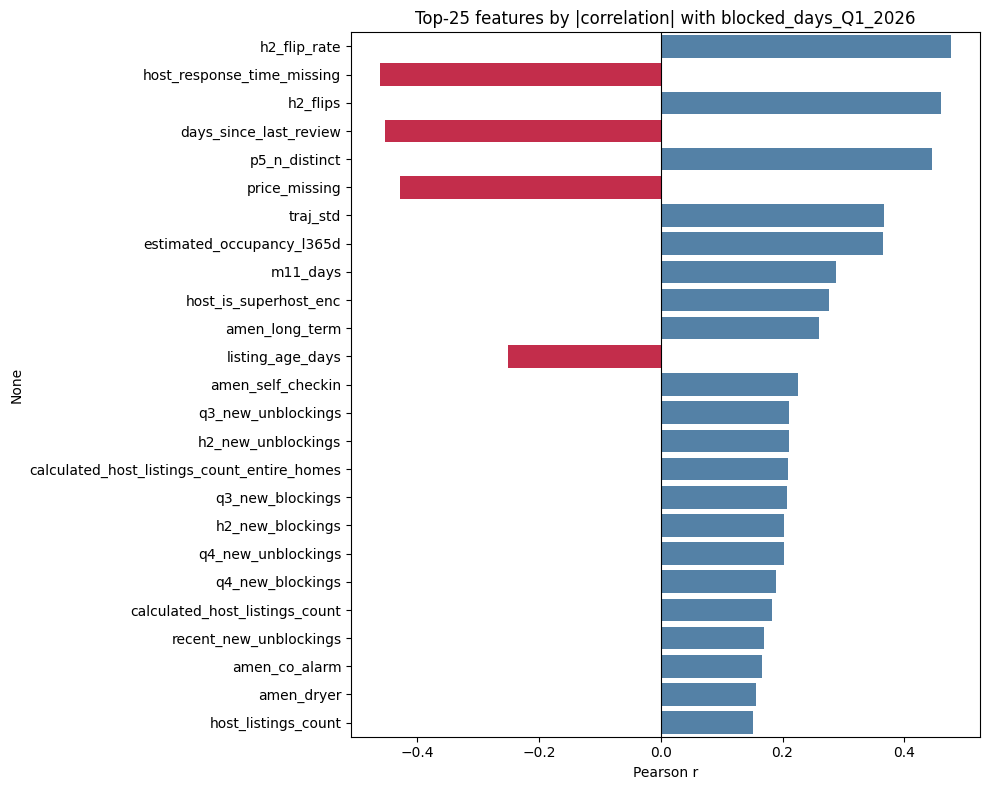

In [27]:
top25 = corr_target.head(25)
colors = ['crimson' if v < 0 else 'steelblue' for v in top25.values]

fig, ax = plt.subplots(figsize=(10, 8))
import seaborn as sns
sns.barplot(x=top25.values, y=top25.index, ax=ax, palette=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top-25 features by |correlation| with blocked_days_Q1_2026')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.savefig(Path('../outputs') / 'fe_top_correlations.png', dpi=120)
plt.show()

In [28]:
# Print full feature inventory grouped by source
groups = {
    'Calendar Q3' :   [c for c in feat.columns if c.startswith('q3_')],
    'Calendar Q4' :   [c for c in feat.columns if c.startswith('q4_')],
    'Calendar H2' :   [c for c in feat.columns if c.startswith('h2_')],
    'Calendar Monthly': [c for c in feat.columns if c.startswith('m') and '_blocking' in c],
    'Recency'     :   [c for c in feat.columns if c.startswith('recent_')],
    'Trajectory'  :   [c for c in feat.columns if c.startswith('traj_')],
    'Cross-table' :   [c for c in feat.columns if 'trend' in c or 'ratio' in c],
    'Reviews'     :   [c for c in feat.columns if c.startswith('rev_')],
    'Price'       :   [c for c in feat.columns if 'price' in c or 'revenue' in c or 'occupancy' in c],
    'Review scores':  [c for c in feat.columns if c.startswith('review_scores_') or c == 'reviews_per_month'],
    'Property type':  [c for c in feat.columns if 'property_type_grp' in c or 'room_type' in c],
    'Amenities'   :   [c for c in feat.columns if c.startswith('amen_')],
    'Keywords'    :   [c for c in feat.columns if c.startswith('kw_') or c.startswith('title_')],
    'Borough'     :   [c for c in feat.columns if 'neighbourhood_group_cleansed' in c or c == 'neighbourhood_freq'],
    'Nbhd/geo context': [c for c in feat.columns if c.startswith('nb_') or c.startswith('geo_mean') or c.startswith('geo_density') or c.startswith('rate_vs_')],
    'Raw categorical (per-fold OneHot in model notebooks)': [c for c in feat.columns if c == 'neighbourhood_cleansed'],
    'Geography'   :   ['latitude', 'longitude'] + [c for c in feat.columns if c.startswith('geo_cluster_')],
    'Host'        :   [c for c in feat.columns if 'host_' in c],
    'Other meta'  :   [c for c in feat.columns if c in [
        'accommodates', 'bedrooms', 'beds', 'bathrooms_num', 'bath_is_shared',
        'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm',
        'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
        'has_reviews', 'price_per_guest', 'min_stay_x_price',
        'listing_age_days', 'days_since_last_review',
    ]],
}

total_feats = 0
for grp, cols in groups.items():
    present = [c for c in cols if c in feat.columns]
    total_feats += len(present)
    print(f'{grp:<20}: {len(present):3d}  {present[:5]}...' if len(present) > 5 else f'{grp:<20}: {len(present):3d}  {present}')
print(f'\nTotal counted: {total_feats} | Actual numeric: {n_num - 1}  (+1 target)')

Calendar Q3         :  14  ['q3_days_total', 'q3_days_blocked', 'q3_days_avail', 'q3_blocking_rate', 'q3_avail_rate']...
Calendar Q4         :  12  ['q4_days_total', 'q4_days_blocked', 'q4_days_avail', 'q4_blocking_rate', 'q4_avail_rate']...
Calendar H2         :  15  ['h2_days_total', 'h2_days_blocked', 'h2_days_avail', 'h2_blocking_rate', 'h2_avail_rate']...
Calendar Monthly    :   6  ['m7_blocking_rate', 'm8_blocking_rate', 'm9_blocking_rate', 'm10_blocking_rate', 'm11_blocking_rate']...
Recency             :  13  ['recent_days_total', 'recent_days_blocked', 'recent_days_avail', 'recent_blocking_rate', 'recent_avail_rate']...
Trajectory          :   7  ['traj_slope', 'traj_recent3', 'traj_older3', 'traj_recent_older_ratio', 'traj_accel']...
Cross-table         :   4  ['p5_trend', 'q3_to_q4_blocking_trend', 'q3_to_q4_blocking_ratio', 'traj_recent_older_ratio']
Reviews             :   5  ['rev_30d', 'rev_90d', 'rev_180d', 'rev_365d', 'rev_accel_90']
Price               :   8  ['estima

## 9. Train / Test Split & Save

In [29]:
# Drop remaining object columns EXCEPT the raw high-cardinality categoricals we
# intentionally keep for per-fold top-K OneHot encoding in each model notebook.
KEEP_RAW_CAT = ['neighbourhood_cleansed']
obj_cols = feat.select_dtypes(include='object').columns.tolist()
obj_cols_drop = [c for c in obj_cols if c != 'id' and c not in KEEP_RAW_CAT]
feat_model = feat.drop(columns=obj_cols_drop)
print(f'Object columns dropped: {obj_cols_drop}')
print(f'Object columns kept (raw categorical): {[c for c in KEEP_RAW_CAT if c in feat_model.columns]}')
print(f'Model-ready matrix: {feat_model.shape}')

# 80/20 random split
train_local, test_local = train_test_split(
    feat_model, test_size=0.20, random_state=RANDOM_STATE, shuffle=True
)
print(f'\nTrain (80%): {train_local.shape}')
print(f'Test  (20%): {test_local.shape}')

# Target check
print(f'\nTrain target — mean={train_local["blocked_days_Q1_2026"].mean():.2f}  '
      f'std={train_local["blocked_days_Q1_2026"].std():.2f}')
print(f'Test  target — mean={test_local["blocked_days_Q1_2026"].mean():.2f}  '
      f'std={test_local["blocked_days_Q1_2026"].std():.2f}')

Object columns dropped: []
Object columns kept (raw categorical): ['neighbourhood_cleansed']
Model-ready matrix: (36261, 208)

Train (80%): (29008, 208)
Test  (20%): (7253, 208)

Train target — mean=16.22  std=25.10
Test  target — mean=15.76  std=24.91


In [30]:
try:
    train_local.to_parquet(OUT_DIR / 'train_local.parquet',  index=False)
    test_local .to_parquet(OUT_DIR / 'test_local.parquet',   index=False)
    feat_model .to_parquet(OUT_DIR / 'all_features.parquet', index=False)
    print('Saved parquet files to', OUT_DIR.resolve())
except Exception as e:
    print('Parquet failed, saving CSV:', e)
    train_local.to_csv(OUT_DIR / 'train_local.csv',  index=False)
    test_local .to_csv(OUT_DIR / 'test_local.csv',   index=False)
    feat_model .to_csv(OUT_DIR / 'all_features.csv', index=False)

print('\nFiles saved:')
for f in OUT_DIR.glob('*.parquet'):
    print(f'  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)')

Saved parquet files to /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs

Files saved:
  all_features.parquet  (6.2 MB)
  train_local.parquet  (5.4 MB)
  test_local.parquet  (1.6 MB)


## Summary

| Feature group | # features | Source |
|---|---|---|
| Calendar Q3 2025 (Jul–Sep) | ~12 | Monthly calendar scrapes |
| Calendar Q4 2025 (Oct–Dec) | ~12 | Monthly calendar scrapes |
| Calendar H2 combined | ~12 | All 6 months |
| Monthly blocking rate M7–M12 | 12 | Per-month calendar |
| Recency window (Dec 4–31) | ~12 | December calendar |
| Trajectory (slope/accel/etc, Section 7.1) | 7 | Derived from monthly rates |
| Cross-table derived | 1 | Q3→Q4 blocking trend |
| Review velocity | 4 | December reviews.csv |
| Price & revenue | ~5 | 5-month (Jul-Nov) average + implied fallback |
| Review scores | 7 | December listings |
| Property type (one-hot) | ~4 | December listings |
| Amenity flags | 14 | December listings |
| Title/description keywords (Section 4.1) | 10 | `name` + `description`, synonym-regex |
| Borough (one-hot) | ~4 | December listings |
| Neighbourhood/geo context (Section 7.2) | 6 | Leakage-safe group means of `recent_blocking_rate` |
| Geography (lat, lon, one-hot cluster) | ~21 | December listings + KMeans (`geo_cluster_*` dummies) |
| Host (incl. `host_response_time_enc`) | ~11 | December listings |
| Other metadata | ~15 | December listings |

**~170 numeric features total** — `availability_30/60/90/365` are excluded as they are
Airbnb's forward-looking calendar counts from the December 2025 scrape date, which
directly overlap the Q1 2026 prediction window and would constitute data leakage.

### Consumed by model notebooks
All model notebooks (`03_Linear_Baseline` → `07_Blend`, `08`-`11`, `15_Hurdle_Model`) load
`train_local.parquet` and `test_local.parquet`.
Target column: **`blocked_days_Q1_2026`** (0–90 days blocked in Jan–Mar 2026), now built from the
**clean multi-snapshot rule** in Section 6 (Oct 2025 – Mar 2026 calendars) rather than a single
December-2025 snapshot. `blocked_days_Q1_2026_naive` (the old single-snapshot count) is computed
and printed in Section 6 purely for the before/after variance comparison — Section 7 only pulls
`blocked_days_Q1_2026` into `feat`, so the naive column never reaches `feat_model` /
`train_local` / `test_local` / `all_features.parquet`.

**Expected effect of this change:** the clean target has meaningfully lower variance than the
naive one (see the `naive/clean variance ratio` printed in Section 6). Downstream models should
land at a **lower MSE** than before, and — because the target itself is genuinely less noisy — a
**lower R2** is expected too. That is not a regression; R2 is relative to target variance, and the
naive target's variance was partly host-block noise, not learnable signal.

**Gap-analysis features added most recently** (vs. the old 2016 Kaggle pipeline / Ali's branch):
trajectory features (Section 7.1), neighbourhood/geo context features (Section 7.2), title/
description keywords with synonym-group regex (Section 4.1), `host_response_time_enc` ordinal
encoding (previously dropped entirely), and one-hot `geo_cluster_*` dummies (previously fed to
models as a raw, falsely-ordinal integer).